<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [2]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')
housing

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768
...,...,...,...,...,...,...,...,...,...,...,...,...
980,9169 GARLINGTON CT,SACRAMENTO,95829,CA,4,3,2280,Residential,Thu May 15 00:00:00 EDT 2008,232425,38.457679,-121.359620
981,6932 RUSKUT WAY,SACRAMENTO,95823,CA,3,2,1477,Residential,Thu May 15 00:00:00 EDT 2008,234000,38.499893,-121.458890
982,7933 DAFFODIL WAY,CITRUS HEIGHTS,95610,CA,3,2,1216,Residential,Thu May 15 00:00:00 EDT 2008,235000,38.708824,-121.256803
983,8304 RED FOX WAY,ELK GROVE,95758,CA,4,2,1685,Residential,Thu May 15 00:00:00 EDT 2008,235301,38.417000,-121.397424


### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [3]:
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [4]:
housing['sale_date'] = pd.to_datetime(housing['sale_date'], format="%a %b %d %H:%M:%S EDT %Y")

In [5]:
housing.dtypes

street                  str
city                    str
zip                   int64
state                   str
beds                  int64
baths                 int64
sq__ft                int64
type                    str
sale_date    datetime64[us]
price                 int64
latitude            float64
longitude           float64
dtype: object

In [6]:
housing

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768
...,...,...,...,...,...,...,...,...,...,...,...,...
980,9169 GARLINGTON CT,SACRAMENTO,95829,CA,4,3,2280,Residential,2008-05-15,232425,38.457679,-121.359620
981,6932 RUSKUT WAY,SACRAMENTO,95823,CA,3,2,1477,Residential,2008-05-15,234000,38.499893,-121.458890
982,7933 DAFFODIL WAY,CITRUS HEIGHTS,95610,CA,3,2,1216,Residential,2008-05-15,235000,38.708824,-121.256803
983,8304 RED FOX WAY,ELK GROVE,95758,CA,4,2,1685,Residential,2008-05-15,235301,38.417000,-121.397424


When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [7]:
housing.describe()

,zip,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,985.000000,985.000000,985.000000,985.000000,985,985.000000,985.000000,985.000000
mean,95750.697462,2.911675,1.776650,1312.918782,2008-05-18 05:12:51.167512,233715.951269,38.445121,-121.193371
min,95603.000000,0.000000,0.000000,-984.000000,2008-05-15 00:00:00,-210944.000000,-121.503471,-121.551704
25%,95660.000000,2.000000,1.000000,950.000000,2008-05-16 00:00:00,145000.000000,38.482704,-121.446119
50%,95762.000000,3.000000,2.000000,1304.000000,2008-05-19 00:00:00,213750.000000,38.625932,-121.375799
75%,95828.000000,4.000000,2.000000,1718.000000,2008-05-20 00:00:00,300000.000000,38.695589,-121.294893
max,95864.000000,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.020808,38.668433
std,85.176072,1.307932,0.895371,856.123224,NaN,139088.818896,5.103637,5.100670


In [8]:
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [9]:
housing = housing[(housing['sq__ft'] > 0) & (housing['price'] > 0)]

In [10]:
housing.describe()

,zip,beds,baths,sq__ft,sale_date,price,latitude,longitude
count,813.000000,813.000000,813.000000,813.000000,813,813.000000,813.000000,813.000000
mean,95761.400984,3.247232,1.961870,1591.892989,2008-05-18 05:01:06.420664,229471.130381,38.576931,-121.378533
min,95603.000000,1.000000,1.000000,484.000000,2008-05-15 00:00:00,2000.000000,38.241514,-121.550527
25%,95670.000000,3.000000,2.000000,1144.000000,2008-05-16 00:00:00,148750.000000,38.473814,-121.451444
50%,95820.000000,3.000000,2.000000,1419.000000,2008-05-19 00:00:00,207973.000000,38.591618,-121.404999
75%,95828.000000,4.000000,2.000000,1851.000000,2008-05-20 00:00:00,285000.000000,38.674864,-121.325730
max,95864.000000,8.000000,5.000000,5822.000000,2008-05-21 00:00:00,884790.000000,39.008159,-120.597599
std,85.357516,0.849012,0.669367,663.908347,NaN,119897.576889,0.126352,0.119730


In [11]:
housing.shape

(813, 12)

In [12]:
housing.duplicated().sum()

np.int64(2)

In [13]:
housing = housing.drop_duplicates()

In [14]:
housing.to_csv('./data/sacramento_cleaned_dataframe.csv', index=False)

In [15]:
housing

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768
...,...,...,...,...,...,...,...,...,...,...,...,...
980,9169 GARLINGTON CT,SACRAMENTO,95829,CA,4,3,2280,Residential,2008-05-15,232425,38.457679,-121.359620
981,6932 RUSKUT WAY,SACRAMENTO,95823,CA,3,2,1477,Residential,2008-05-15,234000,38.499893,-121.458890
982,7933 DAFFODIL WAY,CITRUS HEIGHTS,95610,CA,3,2,1216,Residential,2008-05-15,235000,38.708824,-121.256803
983,8304 RED FOX WAY,ELK GROVE,95758,CA,4,2,1685,Residential,2008-05-15,235301,38.417000,-121.397424


### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

In [16]:
housing.corr(numeric_only = True)[['price']]

,price
zip,-0.220160
beds,0.442892
baths,0.501123
sq__ft,0.693247
price,1.000000
latitude,0.058967
longitude,0.278226


<Axes: xlabel='sq__ft', ylabel='price'>

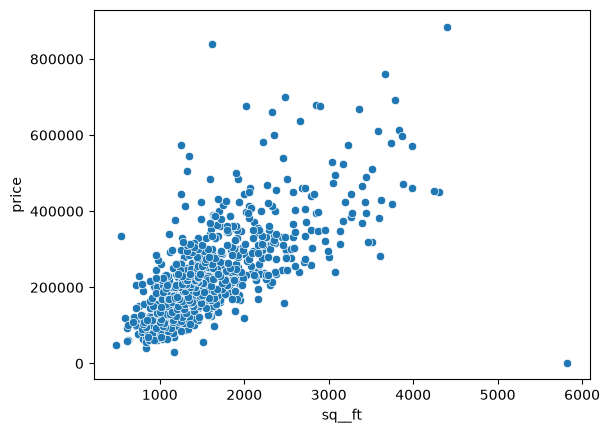

In [17]:
sns.scatterplot(data = housing, x = 'sq__ft', y = 'price')


In [18]:
pd.crosstab(index = housing['baths'], columns = ['price'])

col_0,price
baths,
1,177
2,506
3,110
4,17
5,1


<Axes: xlabel='beds', ylabel='price'>

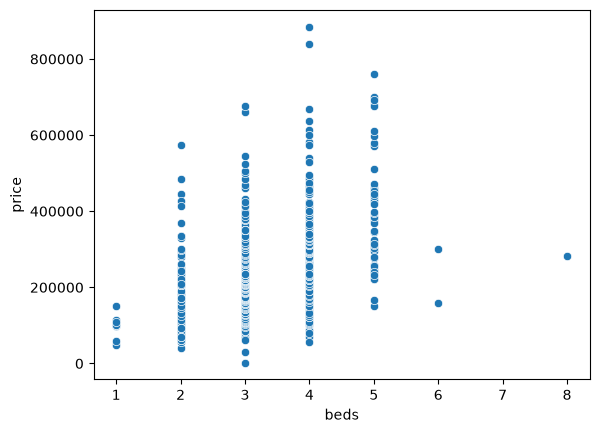

In [19]:
sns.scatterplot(data = housing, x = 'beds', y = 'price')

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

Square Feet, becuase it showed the highest correlation with price at 69%, hence moderate relationship with price movements.

### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [20]:
def statistics (x,y):
    x_list = np.array(x)
    y_list = np.array(y)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_std = np.std(x)
    y_std = np.std(y)
    correlation = np.corrcoef(x,y)[0,1]
    coefficient = correlation * (y_std/x_std)
    intercept = y_mean - coefficient*x_mean
    return intercept, coefficient


### 6. Interpret the intercept and the slope.

In [21]:
x = housing['sq__ft']
y = housing['price']
statistics(x,y)

(np.float64(30352.243076665123), np.float64(125.15261406074985))

### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

In terms of prediction and the calculated coefficient the model shows a strong relevant relationship with price predictions where a single increase in sqaure feet will result in an 125 price boost. Moreover, the model can be utilized in inference since the model can be used to determine whether square footage is a significant predictor of house price and estimate how much the average price changes for each additional square foot.

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

In [22]:
def statistics (x,y):
    x_list = np.array(x)
    y_list = np.array(y)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_std = np.std(x)
    y_std = np.std(y)
    correlation = np.corrcoef(x,y)[0,1]
    coefficient = correlation * (y_std/x_std)
    intercept = y_mean - coefficient*x_mean
    y_pred = coefficient * x + intercept
    residuals = y - y_pred
    return intercept, coefficient, residuals


In [23]:
x = housing['sq__ft']
y = housing['price']
statistics(x,y)

(np.float64(30352.243076665123),
 np.float64(125.15261406074985),
 0      -75757.828431
 1     -108193.343686
 2      -61093.723869
 3      -67675.270256
 4      -48198.876483
            ...      
 980    -83275.203135
 981     18797.345956
 982     52462.178225
 983     -5933.397769
 984     34927.896573
 Length: 811, dtype: float64)

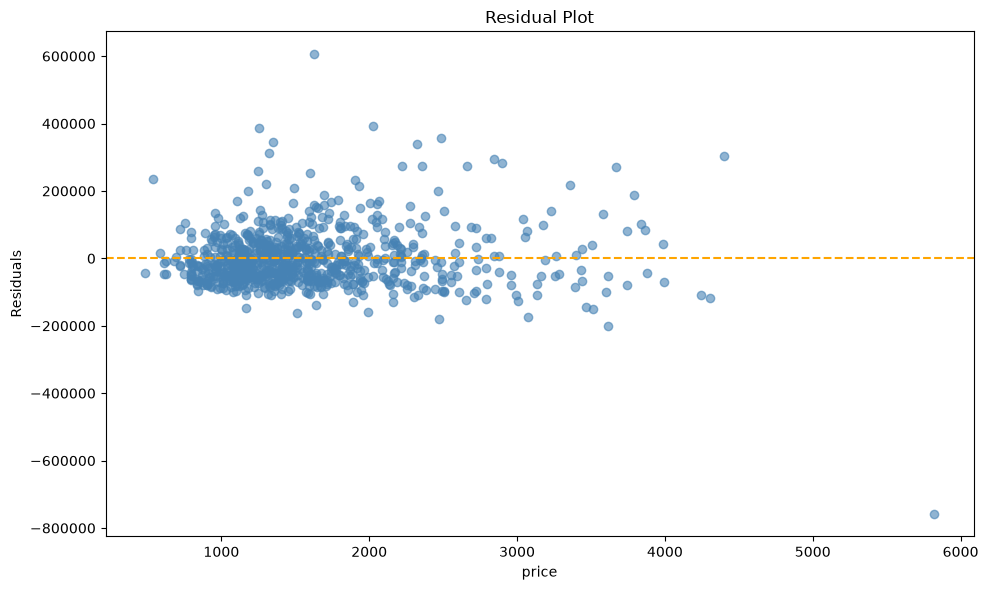

In [24]:
intercept, coefficient, residuals = statistics(x, y)

plt.figure(figsize=(10,6))
plt.scatter(x, residuals, alpha=0.6, color='steelblue')
plt.axhline(y=0, color='orange', linestyle='--')
plt.xlabel('price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [25]:
housing_dummies = pd.get_dummies(housing, columns = ['type'], drop_first=True, dtype=int)

### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [26]:
housing_dummies.head()

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,0,1
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,0,1
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,0,1
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,0,1
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,0,1


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [27]:
x = housing_dummies[['sq__ft','baths','type_Multi-Family','type_Residential']]
y = housing_dummies['price']
model = LinearRegression()
model.fit(x,y)
y_pred = model.predict(x)
print("Intercept:" , model.intercept_)
print("Coefficients:", dict(zip(x,model.coef_)))

Intercept: 8307.061816777743
Coefficients: {'sq__ft': np.float64(122.38841243168355), 'baths': np.float64(3106.8842010805424), 'type_Multi-Family': np.float64(-43851.6789591101), 'type_Residential': np.float64(22555.040005317453)}


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

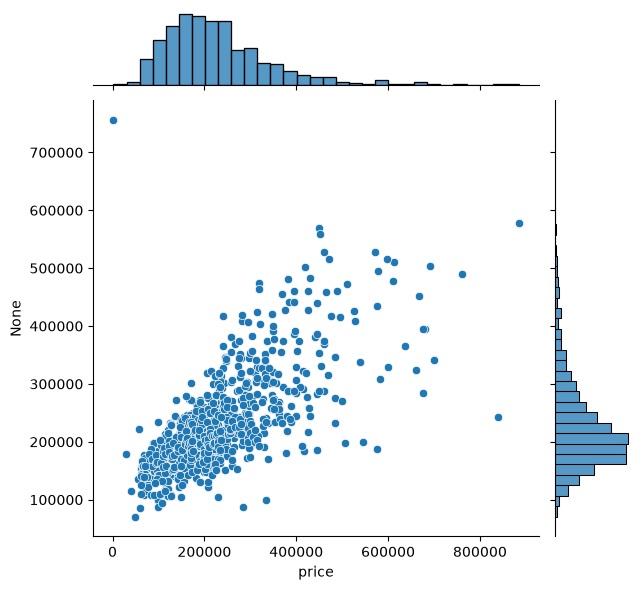

In [28]:
sns.jointplot(data = housing_dummies, x=y, y=y_pred)

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

LINE
- Linearaty
- Independence
- Normality
- Equality
- Multicollinearity

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

Linerity: I believe the linearity assumption is reasonably met. The scatter plot of sq_ft versus price shows a positive linear trend, indicating that as square footage increases, house price generally increases. While there is some variability, a straight line appears to describe the overall relationship.
Multicollinearity: Since this model uses only one predictor (sq_ft), multicollinearity is not an issue. Multicollinearity only occurs when there are multiple predictor variables that are highly correlated with one another.


### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [29]:
def r2_adj(x, y, r2):
    n = len(y)
    k = x.shape[1]

    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
    return adjusted_r2

r2 = model.score(x, y)
print("Adjusted R2:", r2_adj(x, y, r2))

Adjusted R2: 0.4842444363610937


### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [30]:
rscore = r2_score(y,y_pred)
mean_absolute = mean_absolute_error(y,y_pred)
sq_error = np.sqrt(mean_squared_error(y,y_pred))
adjusted_r = r2_adj(x, y, r2)

print(rscore)
print(mean_absolute)
print(sq_error)
print(adjusted_r)

0.4867913774161007
59875.242045856845
85835.3438362166
0.4842444363610937


### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [31]:
housing_dummies.corr(numeric_only = True)[['price']]

,price
zip,-0.220160
beds,0.442892
baths,0.501123
sq__ft,0.693247
price,1.000000
latitude,0.058967
longitude,0.278226
type_Multi-Family,-0.005552
type_Residential,0.167653


In [32]:
x_new_features = housing_dummies[['sq__ft' , 'baths' , 'type_Residential']]
y = housing_dummies['price']

linear = LinearRegression()
linear.fit(x_new_features,y)
y_pred_new = linear.predict(x_new_features)

rscore_new = r2_score(y,y_pred_new)
adj_r2_new = r2_adj(x_new_features,y,rscore_new)
mean_absolute = mean_absolute_error(y,y_pred_new)
sq_error = np.sqrt(mean_squared_error(y,y_pred_new))

print(rscore_new)
print(adj_r2_new)
print(mean_absolute)
print(sq_error)

0.4852853804996873
0.48337194325247423
60018.51413483763
85961.19233441578


### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [33]:
city_count = housing_dummies['city'].value_counts()
grouped_citties = city_count[city_count < 20].index

housing_dummies['cities_grouped'] = housing_dummies['city'].replace(grouped_citties, 'Other')
OHE = OneHotEncoder(sparse_output=False, drop = 'first')
city_encoded = OHE.fit_transform(housing_dummies[['cities_grouped']])
city_df = pd.DataFrame(city_encoded,
    columns = OHE.get_feature_names_out(['cities_grouped']),
    index = housing_dummies.index)
x_city = pd.concat([housing_dummies[['sq__ft', 'baths' , 'type_Residential']],city_df], axis=1)
y_city = housing_dummies['price']

model_city = LinearRegression()
model_city.fit(x_city,y_city)
y_pred_city = model_city.predict(x_city)
rscore_city = r2_score(y_city, y_pred_city)
rmse_city = np.sqrt(mean_squared_error(y_city,y_pred_city))

print(F" The R2 Score of Cities: {rscore_city}")
print(F" The RMSE Score of Cities: {rmse_city}")

                                 

 The R2 Score of Cities: 0.5567006082007471
 The RMSE Score of Cities: 79775.17152532941


## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [34]:
y_baseline = np.full_like(y,fill_value = y.mean())
mean_baseline = mean_absolute_error(y,y_baseline)
mean_mlr = mean_absolute_error(y,y_pred_city)

Saved_Errors = mean_baseline - mean_mlr

print(F"Mean Price of Baseline: {mean_baseline}")
print(F"Mean Price of MLR: {mean_mlr}")
print(F"The errors saved are: {Saved_Errors}")
                        

Mean Price of Baseline: 88310.40690505548
Mean Price of MLR: 53877.006586649724
The errors saved are: 34433.40031840576


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [37]:
X_train,X_test,y_train,y_test = train_test_split(x_city,y,test_size = 0.3, random_state = 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
linear = LinearRegression()
linear.fit(X_train_scaled,y_train)
coefficient = pd.Series(linear.coef_, index = X_train.columns)
print(F"Scaled Coefficients Sorted: {coefficient.sort_values(key=abs,ascending = False)}")

Scaled Coefficients Sorted: sq__ft                            67649.131494
cities_grouped_Other              31033.238166
cities_grouped_CARMICHAEL         14050.006726
cities_grouped_ROSEVILLE          12508.437304
cities_grouped_ELK GROVE           8966.982620
baths                              7157.438008
type_Residential                   7040.197313
cities_grouped_NORTH HIGHLANDS    -5528.165248
cities_grouped_SACRAMENTO          3769.589253
cities_grouped_GALT                2611.587079
cities_grouped_RANCHO CORDOVA      1798.760815
cities_grouped_CITRUS HEIGHTS      1465.538829
dtype: float64


After sorting the coefficients, we can conclude with a notable statement that the sqaure feet feature contributes the most in determining the house price with a scaled coefficient of (67649.13).

### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [56]:
y_pred_train = linear.predict(X_train_scaled)
y_pred_test = linear.predict(X_test_scaled)

rmse_train = np.sqrt(mean_squared_error(y_train,y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test,y_pred_test))

print(F"RMSE for training is: {rmse_train}")
print(F"RMSE for testing is: {rmse_test}")

RMSE for training is: 83737.92905298714
RMSE for testing is: 70422.19710508148


By examining the output of both RMSE calculations, we can confirm that the model generalizes the real world in good capability due to low error count in testing compared to training, avoiding the path of overfit models.

### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

Based on the RMSE values and regression metrics, the model appears to be in the sweet spot rather than suffering from high bias or high variance. There is no significant drop off in performance between the training set (RMSE of 83,738) and the testing set (RMSE of 70,422)  in fact, the test error is slightly lower, indicating the model generalizes well to unseen data rather than overfitting. This, combined with the meaningful error reduction versus the baseline mean-price model, suggests that the model has captured real signal in the data without simply memorizing the training set. The fact that test error is marginally lower than train error is likely attributable to the specific random split between train and test rather than a sign of a deeper issue.

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

In [57]:
OHE = OneHotEncoder(sparse_output=False, drop='first')
city_encoded = OHE.fit_transform(housing_dummies[['city']])
city_df = pd.DataFrame(city_encoded,
    columns = OHE.get_feature_names_out(['city']),
    index = housing_dummies.index)

x_city = pd.concat([housing_dummies[['sq__ft', 'baths', 'type_Residential']], city_df], axis=1)
y_city = housing_dummies['price']

X_train, X_test, y_train, y_test = train_test_split(x_city, y_city, test_size=0.3, random_state=1)

model_city = LinearRegression()
model_city.fit(X_train, y_train)

y_pred_train = model_city.predict(X_train)
y_pred_test = model_city.predict(X_test)

rscore_train = r2_score(y_train, y_pred_train)
rscore_test = r2_score(y_test, y_pred_test)

print(F" The R2 Score of Cities (Train): {rscore_train}")
print(F" The R2 Score of Cities (Test): {rscore_test}")

 The R2 Score of Cities (Train): 0.66652165550305
 The R2 Score of Cities (Test): 0.6044311128255515


The removal of groupings allowed the model to perform and memeorize better on training data, however it lacked ability in  forecasting unforseen data thus the grouping we configured previously resolved this issue.

### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?

The model was constructed to determine the house prices based on multpile features like square feet, property type, number of baths and such, from multiple complex analysis the square feet feature showed the highest impact in which house prices derive from thus forming a conclusion that the bigger the house area, the more costly it will be to acquire along with location and additional details.